Training R²: 0.9842
Training MSE: 0.01092

Forecast sample:
        date  predicted_press_mean
0 1984-01-01              8.155775
1 1984-01-02              8.164902
2 1984-01-03              8.151391
3 1984-01-04              8.151876
4 1984-01-05              8.151390
            date  predicted_press_mean
17162 2030-12-27              8.151396
17163 2030-12-28              8.151396
17164 2030-12-29              8.151396
17165 2030-12-30              8.151396
17166 2030-12-31              8.151396


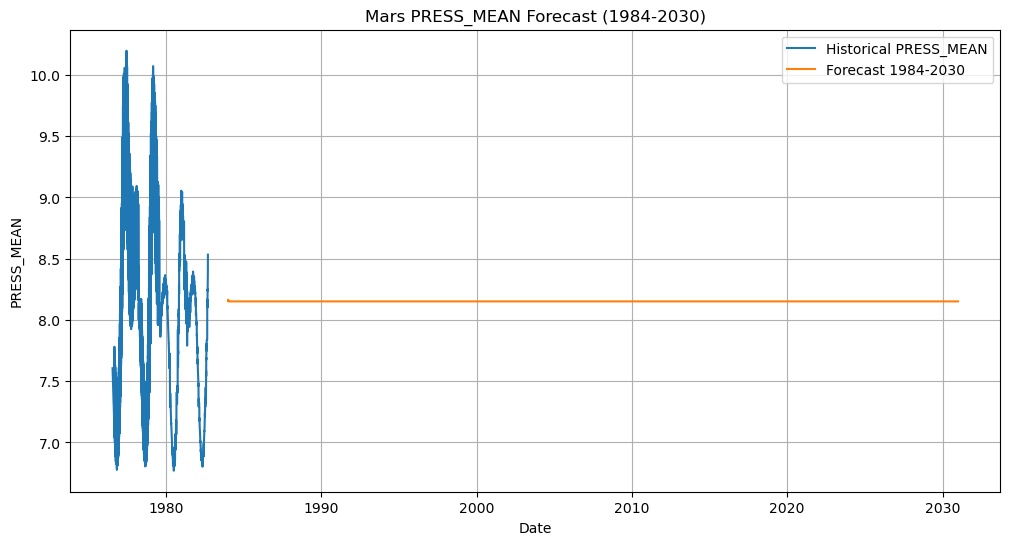

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
df = pd.read_csv("C:/Users/prabh/Documents/Mars_Dataset/Mars_DataSet_v1.csv")

# Clean columns
df.columns = df.columns.str.strip().str.lower()

# Parse date
df["date"] = pd.to_datetime(df["date"], format="%d-%b-%y", errors="coerce")
df = df.sort_values("date")

# Keep needed columns
df = df[["date", "press_mean", "press_max"]]

# Replace invalid values
df = df.replace(-9.999, np.nan).dropna()

# Create lag features
df["lag1"] = df["press_mean"].shift(1)
df["lag2"] = df["press_mean"].shift(2)

# Drop missing rows
df_ts = df.dropna().copy()

# Train model
X = df_ts[["lag1", "lag2", "press_max"]]
y = df_ts["press_mean"]

model = LinearRegression()
model.fit(X, y)

# Training performance
y_train_pred = model.predict(X)
r2 = r2_score(y, y_train_pred)
mse = mean_squared_error(y, y_train_pred)

print("Training R²:", round(r2, 4))
print("Training MSE:", round(mse, 6))

# Future dates
future_dates = pd.date_range(start="1984-01-01", end="2030-12-31", freq="D")
future_df = pd.DataFrame({"date": future_dates})

# Start with last known values
last_lag1 = df_ts["press_mean"].iloc[-1]
last_lag2 = df_ts["press_mean"].iloc[-2]
last_press_max = df_ts["press_max"].mean()   # simple assumption

future_predictions = []

for _ in range(len(future_df)):
    X_input = pd.DataFrame({
        "lag1": [last_lag1],
        "lag2": [last_lag2],
        "press_max": [last_press_max]
    })

    pred = model.predict(X_input)[0]
    future_predictions.append(pred)

    last_lag2 = last_lag1
    last_lag1 = pred

future_df["predicted_press_mean"] = future_predictions

# Show only a few rows
print("\nForecast sample:")
print(future_df.head())
print(future_df.tail())

# Plot historical + forecast
plt.figure(figsize=(12, 6))
plt.plot(df_ts["date"], df_ts["press_mean"], label="Historical PRESS_MEAN")
plt.plot(future_df["date"], future_df["predicted_press_mean"], label="Forecast 1984-2030")
plt.xlabel("Date")
plt.ylabel("PRESS_MEAN")
plt.title("Mars PRESS_MEAN Forecast (1984-2030)")
plt.legend()
plt.grid(True)
plt.show()

SARIMA Results
----------------------------------------
MSE : 0.401558
RMSE: 0.633686
MAE : 0.503729


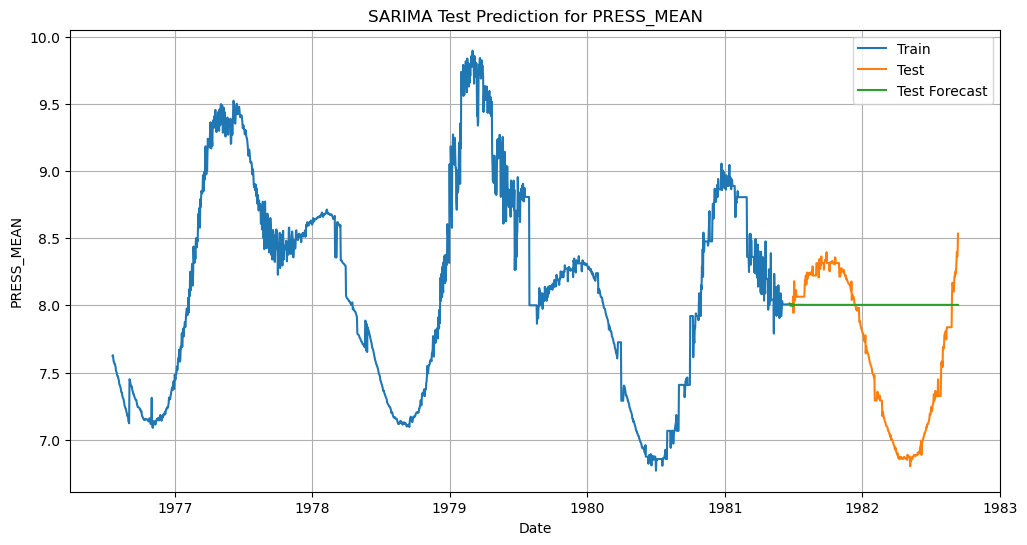

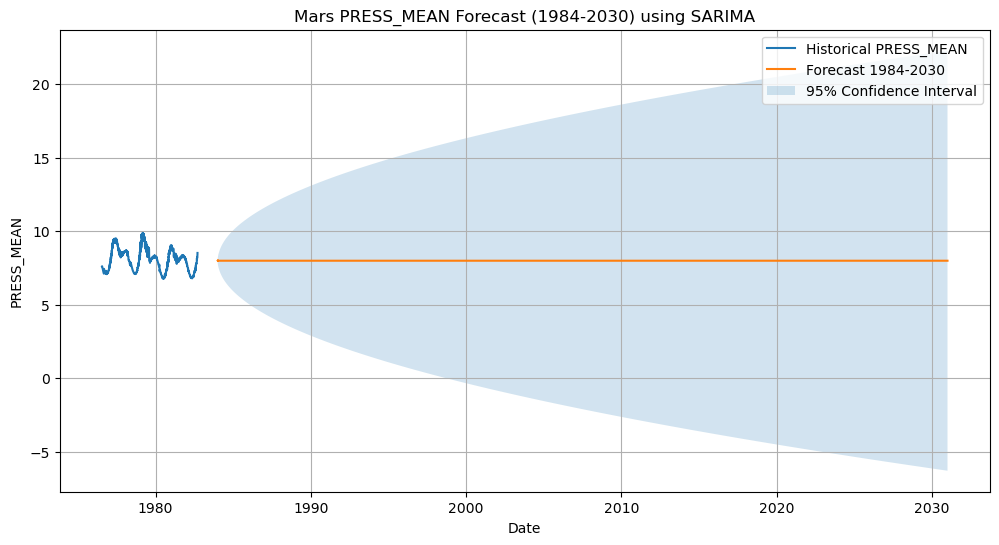


Forecast file saved as:
C:/Users/prabh/Documents/Mars_Dataset/Mars_PRESS_MEAN_Forecast_1984_2030.csv

Forecast sample:
        date  predicted_press_mean  lower_ci  upper_ci
0 1984-01-01              8.011660  7.844543  8.178777
1 1984-01-02              8.003473  7.814484  8.192461
2 1984-01-03              8.013311  7.801259  8.225363
3 1984-01-04              8.003535  7.765913  8.241156
4 1984-01-05              7.999190  7.744038  8.254343
            date  predicted_press_mean  lower_ci   upper_ci
17162 2030-12-27              8.003258 -6.280659  22.287176
17163 2030-12-28              8.003258 -6.281076  22.287592
17164 2030-12-29              8.003258 -6.281492  22.288009
17165 2030-12-30              8.003258 -6.281908  22.288425
17166 2030-12-31              8.003258 -6.282324  22.288841


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -----------------------------------
# 1. Load dataset
# -----------------------------------
df = pd.read_csv("C:/Users/prabh/Documents/Mars_Dataset/Mars_DataSet_v1.csv")

# -----------------------------------
# 2. Clean columns
# -----------------------------------
df.columns = df.columns.str.strip().str.lower()

# -----------------------------------
# 3. Parse date and keep needed columns
# -----------------------------------
df["date"] = pd.to_datetime(df["date"], format="%d-%b-%y", errors="coerce")
df = df.sort_values("date")
df = df[["date", "press_mean"]]

# -----------------------------------
# 4. Replace invalid values and drop missing
# -----------------------------------
df["press_mean"] = df["press_mean"].replace(-9.999, np.nan)
df = df.dropna()

# -----------------------------------
# 5. Set date index
# -----------------------------------
df = df.set_index("date")

# If daily frequency is not regular, resample to daily and interpolate
df = df.resample("D").mean()
df["press_mean"] = df["press_mean"].interpolate()

# -----------------------------------
# 6. Train/test split
# -----------------------------------
split_index = int(len(df) * 0.8)
train = df.iloc[:split_index]
test = df.iloc[split_index:]

# -----------------------------------
# 7. Fit SARIMA model
# Change these values if needed
# order=(p,d,q), seasonal_order=(P,D,Q,s)
# For daily data with yearly-like seasonality, s can be large.
# Start simple:
# -----------------------------------
model = SARIMAX(
    train["press_mean"],
    order=(2, 1, 2),
    seasonal_order=(1, 0, 1, 30),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# -----------------------------------
# 8. Predict on test data
# -----------------------------------
test_pred = results.forecast(steps=len(test))

# -----------------------------------
# 9. Evaluate
# -----------------------------------
mse = mean_squared_error(test["press_mean"], test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test["press_mean"], test_pred)

print("SARIMA Results")
print("-" * 40)
print("MSE :", round(mse, 6))
print("RMSE:", round(rmse, 6))
print("MAE :", round(mae, 6))

# -----------------------------------
# 10. Forecast future: 1984 to 2030
# -----------------------------------
future_dates = pd.date_range(start="1984-01-01", end="2030-12-31", freq="D")
n_future = len(future_dates)

future_forecast = results.get_forecast(steps=n_future)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

# Put into dataframe
forecast_df = pd.DataFrame({
    "date": future_dates,
    "predicted_press_mean": future_mean.values,
    "lower_ci": future_ci.iloc[:, 0].values,
    "upper_ci": future_ci.iloc[:, 1].values
})

# -----------------------------------
# 11. Plot test prediction
# -----------------------------------
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["press_mean"], label="Train")
plt.plot(test.index, test["press_mean"], label="Test")
plt.plot(test.index, test_pred, label="Test Forecast")
plt.title("SARIMA Test Prediction for PRESS_MEAN")
plt.xlabel("Date")
plt.ylabel("PRESS_MEAN")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------------
# 12. Plot future forecast
# -----------------------------------
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["press_mean"], label="Historical PRESS_MEAN")
plt.plot(forecast_df["date"], forecast_df["predicted_press_mean"], label="Forecast 1984-2030")
plt.fill_between(
    forecast_df["date"],
    forecast_df["lower_ci"],
    forecast_df["upper_ci"],
    alpha=0.2,
    label="95% Confidence Interval"
)
plt.title("Mars PRESS_MEAN Forecast (1984-2030) using SARIMA")
plt.xlabel("Date")
plt.ylabel("PRESS_MEAN")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------------
# 13. Save forecast to CSV
# -----------------------------------
forecast_df.to_csv("C:/Users/prabh/Documents/Mars_Dataset/Mars_PRESS_MEAN_Forecast_1984_2030.csv", index=False)

print("\nForecast file saved as:")
print("C:/Users/prabh/Documents/Mars_Dataset/Mars_PRESS_MEAN_Forecast_1984_2030.csv")

print("\nForecast sample:")
print(forecast_df.head())
print(forecast_df.tail())